# Read and plot the original source

Same complete `All_strains` readout and plotting options as `read_atst.ipynb`. Source ranges and condition annotations remain explicit; no ATST file is read. Matplotlib plots the source values directly.


In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
from openpyxl import load_workbook

readout_id = "All_strains"
rows, curves = [], []

book = load_workbook(
    "read_shared_data/sources/12866_2019_1481_MOESM7_ESM.xlsx",
    read_only=True,
    data_only=True,
)
# Source block positions; workbook means and SD columns are omitted.
for sheet_name, isolate, dose, control, infected, time_col in [
    ("Plan1", "Lfar01", "1000000", 21, 7, 2),
    ("Plan1", "Lfar01", "10000000", 51, 37, 2),
    ("Plan2", "ATCC_27853", "10000000", 6, 21, 1),
    ("Plan3", "BOIJ02", "10000000", 7, 22, 1),
]:
    sheet = book[sheet_name]
    for phage, first in [("", control), ("BrSP1", infected)]:
        time = [
            float(
                str(sheet.cell(r, time_col).value)
                .replace("T", "")
                .replace("=", "")
                .strip()
            )
            for r in range(first, first + 8)
        ]
        for replicate in range(1, 4):
            rows.append(
                {
                    "type": "phage_exposed" if phage else "uninfected_control",
                    "isolate_id": isolate,
                    "phage_id": phage,
                    "pfu_ml": dose if phage else "0",
                    "replicate": str(replicate),
                }
            )
            curves.append(
                pd.Series(
                    [
                        sheet.cell(r, time_col + replicate).value
                        for r in range(first, first + 8)
                    ],
                    index=time,
                )
            )

# Local curve IDs preserve source order; different time grids align without interpolation.
layout = pd.DataFrame(rows)
layout["curve_id"] = [f"curve_{i}" for i in range(1, len(rows) + 1)]
readings = pd.concat(curves, axis=1).sort_index()
readings.columns = layout["curve_id"]
readings = readings.rename_axis("Time").reset_index()


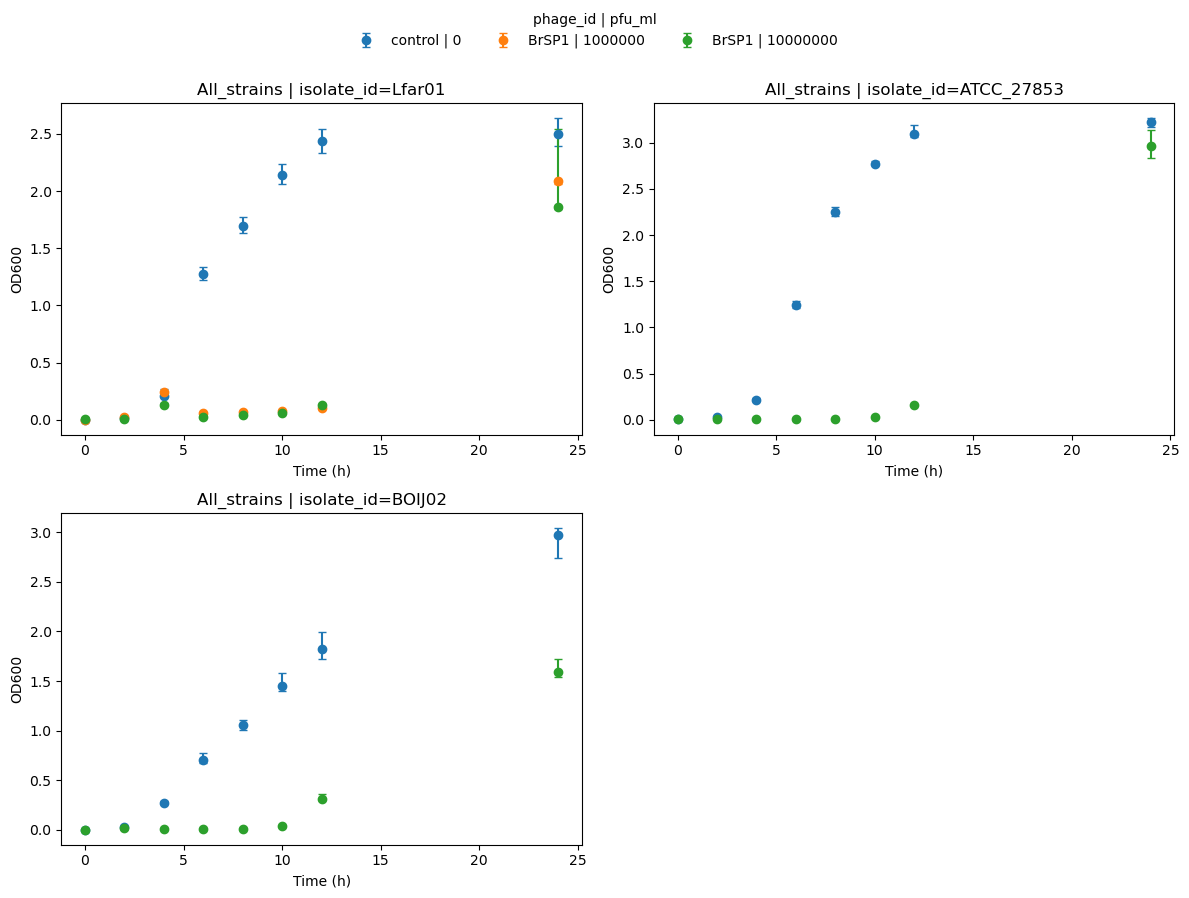

In [2]:
panels = list(layout.groupby("isolate_id", sort=False))
ncols = min(2, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby(["phage_id", "pfu_ml"], sort=False):
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = " | ".join(
            "control" if index == 0 and (pd.isna(value) or value == "") else str(value)
            for index, value in enumerate(condition)
        )
        values = readings[group["curve_id"]]
        median = values.median(axis=1)
        minimum = values.min(axis=1)
        maximum = values.max(axis=1)
        ax.errorbar(
            readings["Time"],
            median,
            yerr=[median - minimum, maximum - median],
            fmt="o",
            capsize=3,
            color=color,
            label=label,
        )
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("OD600")
    panel_label = "<blank>" if panel == "" else str(panel)
    ax.set_title(f"{readout_id} | isolate_id={panel_label}")

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)
legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='phage_id | pfu_ml', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()


Source curves are shown individually; Lfar01 control replicate IDs repeat across source blocks.
